# Cuaderno 1: Entorno de trabajo y bibliotecas de imágenes

Este cuaderno funciona como punto de partida para la unidad. La idea es que puedas reconocer qué herramientas vamos a usar, para qué sirve cada una y qué diferencias básicas aparecen cuando una misma imagen se abre con distintas bibliotecas.

## Objetivos

- Preparar el entorno de trabajo.
- Importar las bibliotecas centrales del laboratorio.
- Comparar cómo una misma imagen se representa en `OpenCV`, `Matplotlib` y `PIL`.
- Empezar a leer la forma, el tipo de dato y el rango de valores de una imagen.


## Antes de empezar

No hace falta que ya sepas programar con soltura. En este cuaderno vamos a mirar tres ideas muy simples:

1. cómo se importa una biblioteca,
2. cómo se carga una imagen,
3. qué información conviene mirar antes de empezar a procesarla.

La meta no es memorizar código, sino entender qué está pasando cuando una imagen entra al entorno de trabajo.


In [1]:
%pip install opencv-python pillow scikit-image matplotlib -q


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski
from PIL import Image

print(f"Versión de Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"OpenCV: {cv2.__version__}")
print(f"scikit-image: {ski.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")


Versión de Python: 3.12.2
NumPy: 2.4.4
OpenCV: 4.13.0
scikit-image: 0.26.0
Matplotlib: 3.10.8


## ¿Para qué sirve cada biblioteca?

- `NumPy` permite trabajar con matrices. En procesamiento de imágenes esto es clave, porque una imagen digital se representa como una matriz de números.
- `OpenCV` ofrece herramientas muy usadas en visión por computadora.
- `Matplotlib` nos ayuda a visualizar imágenes, gráficos e histogramas.
- `PIL` es útil para abrir, guardar y manipular imágenes desde otra perspectiva.
- `scikit-image` reúne funciones diseñadas específicamente para análisis y procesamiento de imágenes.

No hacen exactamente lo mismo. Por eso conviene conocer el papel de cada una.


In [3]:
ruta_imagen = Path("frutos_rojos.png")
url = "https://www.dropbox.com/s/do6b49d10ty1dyf/frutos_rojos.png?dl=1"

if not ruta_imagen.exists():
    urllib.request.urlretrieve(url, ruta_imagen)

print(f"Imagen disponible en: {ruta_imagen.resolve()}")


Imagen disponible en: C:\Users\usuario\zambrano-michell-pdi-1c-2026\004 - librerias_fundamentos_pdi\002 PRA\frutos_rojos.png


OpenCV
  forma: (512, 512, 3)
  tipo de dato: uint8

Matplotlib
  forma: (512, 512, 4)
  tipo de dato: float32

PIL
  tamaño: (512, 512)
  modo: RGBA


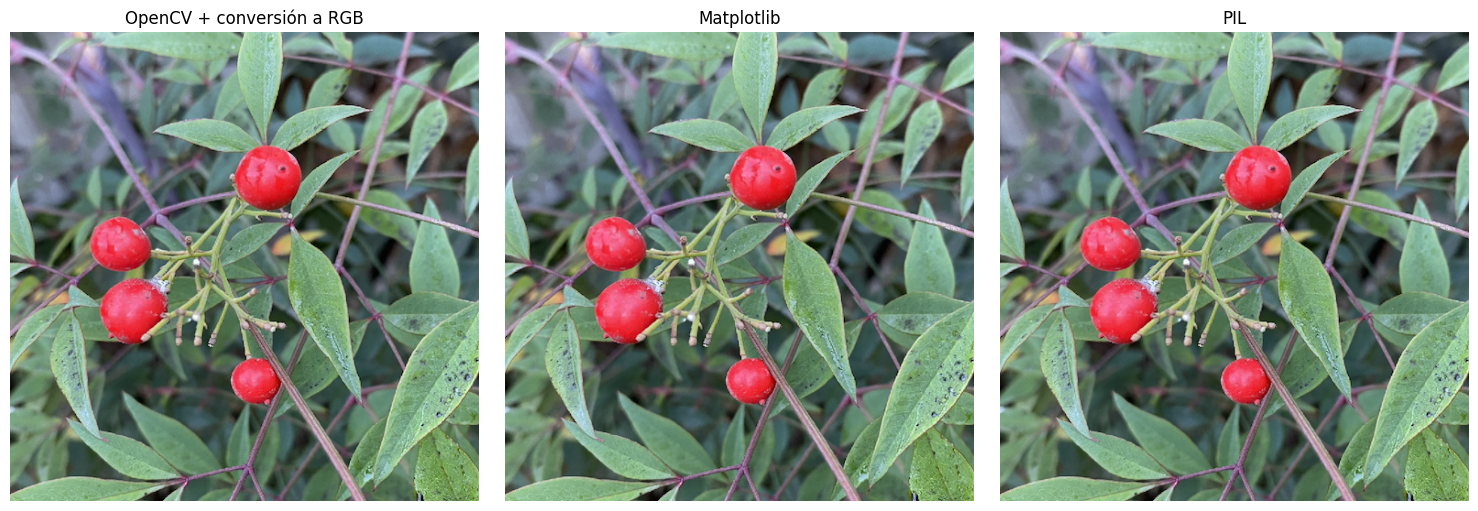

In [4]:
img_cv = cv2.imread(str(ruta_imagen))
img_cv_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
img_plt = plt.imread(ruta_imagen)
img_pil = Image.open(ruta_imagen)

print("OpenCV")
print(f"  forma: {img_cv.shape}")
print(f"  tipo de dato: {img_cv.dtype}")
print()
print("Matplotlib")
print(f"  forma: {img_plt.shape}")
print(f"  tipo de dato: {img_plt.dtype}")
print()
print("PIL")
print(f"  tamaño: {img_pil.size}")
print(f"  modo: {img_pil.mode}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_cv_rgb)
axes[0].set_title("OpenCV + conversión a RGB")
axes[0].axis("off")

axes[1].imshow(img_plt)
axes[1].set_title("Matplotlib")
axes[1].axis("off")

axes[2].imshow(img_pil)
axes[2].set_title("PIL")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Para mirar con calma

- `OpenCV` devuelve un arreglo de `NumPy`.
- `Matplotlib` también trabaja con arreglos, pero no siempre usa el mismo tipo de dato que `OpenCV`.
- `PIL` abre la imagen como un objeto distinto, pensado para otras tareas.

Lo importante es que una imagen no entra siempre al entorno del mismo modo. Antes de procesarla, conviene revisar su forma, su tipo de dato y la biblioteca con la que fue cargada.


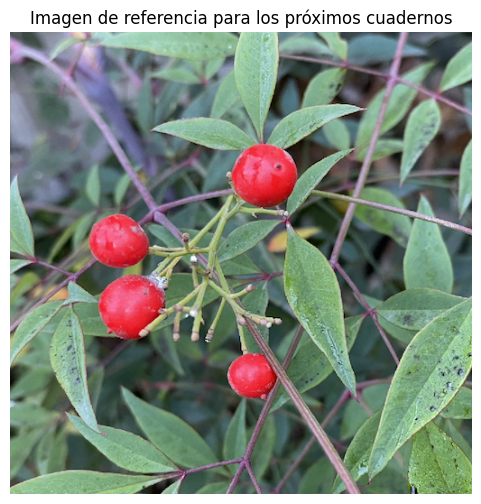

In [5]:
plt.figure(figsize=(6, 6))
plt.imshow(img_cv_rgb)
plt.title("Imagen de referencia para los próximos cuadernos")
plt.axis("off")
plt.show()


## Cierre

En este primer cuaderno preparaste el entorno y viste que una misma imagen puede abrirse con herramientas distintas. En los próximos materiales vamos a concentrarnos en dos ideas centrales:

- cómo se representan los colores,
- cómo una imagen puede tratarse como una matriz sobre la que aplicamos operaciones.
